In [1]:
# перед работой в kernel ставятся необходимые фреймворки 
# для этого возможен список команд:  

# python -m venv vvenvv
# source ./vvenvv/bin/activate
# pip install requirements.txt" 

# так как у меня уже есть .venv и нет requirements.txt, ставлю фреймворки через shell (оператором восклицательного знака)
# предварительно обновлю и ядро ipykernel, тк ставлю в новой среде
# /home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/vvenvv/bin/python -m pip install ipykernel -U  --force-reinstal

!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


# 1. Выбор начальных условий

## a. Набор данных для задачи классификации 

Реальная практическая задача:

Выявление тенденций в мед. страховании между сборами и мед. факторами согласно kaggle-page. 

- __Набор данных__: https://www.kaggle.com/datasets/muhammadanwaar101/healthcare-insurance-charges-dataset

## b. Набор данных для задачи регрессии 

Реальная практическая задача:

Выявление Хронической Болезни Почек и оценки факторов риска функции почек согласно kaggle-page.

- __Набор данных__: https://www.kaggle.com/datasets/miadul/kidney-function-health-dataset

## c. Метрики качества и обоснование выбора


### Классификация:
- __Accuracy__ - процент объектов, верно классифицированных моделью. 
- __F1-score__ - среднее гармоническое между точностью (precision) и полнотой (recall).

### Регрессия:
- __MAE__ - насколько в среднем модель ошибается в прогнозах.
- __R²__ - доля дисперсии целевой переменной, которую объясняет модель. Чем ближе к 1, тем лучше.
- __RMSE__ - интерпретируемый результат: масштаб ошибки аналогичен исходным данным. Штрафует за большие ошибки.


In [2]:
# подгрузка библиотек для получения требуемых методов. 
# библиотечные вызовы именуются в общепринятой сокращенной нотации для читаемости кода
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1.1. загрузка датасета классификации
# задача из реальной предметной области - "факторы, влияющие на страховые выплаты (взносы, сборы)"
clf_csv_pth = "/home/snowwy/Documents/poor_monk/poor_monk/7th_term/about_ai_course/ml/dat_clf.csv"
df_clf = pd.read_csv(clf_csv_pth)

In [4]:
# 1.2 загрузка датасета регрессии
# задача из реальной предметной области - "медицинские записи с биомаркерами"
reg_csv_pth = "dat_reg.csv"
df_reg = pd.read_csv(reg_csv_pth)

In [5]:
# 1.3. исследование датасета  классификации
# производится в одном из двух форматов, доступных в пандасе. 
# взамен одномерному (1-n) series, при работе с csv рекомендуется использовать двумерный (2-n) dataframe

df_clf.head()
# вывод кортежа размерностью dataframe
df_clf_pd = pd.DataFrame(df_clf)

# применение IPython.display позволяет структурированно отобразить в консоли датафрейм
display(df_clf_pd)

,AGE,Gender,Body_Mass_Index(BMI),Number_of_Children,Smoking_Status,Region,Insurance_Charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1402,34,female,27.720,0,no,southeast,4415.15880
1403,42,female,37.900,0,no,southwest,6474.01300
1404,51,female,36.385,3,no,northwest,11436.73815
1405,54,female,27.645,1,no,northwest,11305.93455


In [6]:
# 1.4. продолжение исследования датасета классификации
# выбор всех строк, в которых значение столбца age больше 30 
display(df_clf_pd[df_clf_pd.AGE > 20])

,AGE,Gender,Body_Mass_Index(BMI),Number_of_Children,Smoking_Status,Region,Insurance_Charges
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
...,...,...,...,...,...,...,...
1402,34,female,27.720,0,no,southeast,4415.15880
1403,42,female,37.900,0,no,southwest,6474.01300
1404,51,female,36.385,3,no,northwest,11436.73815
1405,54,female,27.645,1,no,northwest,11305.93455


In [7]:
# 1.5. исследование датасета регрессии
# окинем взглядом первые строки dataframe
df_reg.head()
df_reg.shape
# вывод обобщенного содержимого датафрейма
df_reg.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Creatinine        5000 non-null   float64
 1   BUN               5000 non-null   float64
 2   GFR               5000 non-null   float64
 3   Urine_Output      5000 non-null   float64
 4   Diabetes          5000 non-null   int64  
 5   Hypertension      5000 non-null   int64  
 6   Age               5000 non-null   float64
 7   Protein_in_Urine  5000 non-null   float64
 8   Water_Intake      5000 non-null   float64
 9   Medication        2013 non-null   str    
 10  CKD_Status        5000 non-null   int64  
dtypes: float64(7), int64(3), str(1)
memory usage: 429.8 KB


# 2. Создание бейзлайна и оценка качества

## a. Обучить модели из sklearn (для классификации и регрессии) для выбранных наборов данных



In [23]:
# 2. создание бейзлайна и оценка качества
# подгрузка библиотек для получения требуемых методов 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor # добавлено дерево и визуализация
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, mean_absolute_error, r2_score, mean_squared_error


### classification_а.1. Предобработка датасета классификации

In [16]:
# 2.1. предобработка датасета классификации
# 2.1.1. очистка выбросов (IQR-интерквантильным размахом)
Q1 = df_clf['Insurance_Charges'].quantile(0.25)
Q3 = df_clf['Insurance_Charges'].quantile(0.75)
IQR = Q3 - Q1
df_ins_clean = df_clf[(df_clf['Insurance_Charges'] >= Q1 - 1.5*IQR) & 
                      (df_clf['Insurance_Charges'] <= Q3 + 1.5*IQR)].copy()

# 2.1.2. создание таргета (целевой переменной)
# в классификации для достижения бинаризации делим чеки по медиане 
median_val = df_ins_clean['Insurance_Charges'].median()
df_ins_clean['High_Charge'] = (df_ins_clean['Insurance_Charges'] > median_val).astype(int)

# 2.1.3. выделение признаков и таргета 
X = df_ins_clean.drop(columns=['Insurance_Charges', 'High_Charge'])
y = df_ins_clean['High_Charge']

# 2.1.4. разделение признаков на категориальные и числовые (для классификации) 
cat_cols = X.select_dtypes(include=['object', 'str']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'str']).columns.tolist()

# 2.1.5. конфигурация преобразователя столбцов 
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), # стабильность на новых категориях
    cat_cols) # убран drop='first', для деревьев это не критично
])

### classification_а.2. Бейзлайн классификации

In [17]:
# 2.1.6. создание пайплайна
model_tree = Pipeline([
    ('pre', preprocessor),
    ('clf', DecisionTreeClassifier(
        max_depth=5,              # ограничение глубины во избежание переобучения
        min_samples_leaf=10,      # минимальное кол-во объектов в листе
        class_weight='balanced',  # с балансировкой весов на случай дисбаланса классов
        random_state=42
    ))
])

# 2.1.7. разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, # stratify=y сохраняет баланс классов в обеих частях 
    random_state=42
)

# 2.1.8. обучение модели
model_tree.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

### classification_b. Оценить качество моделей (для классификации) по выбранным метрикам на выбранных наборах данных



Результаты: Доля страхования (Классификация с DECISION TREE)
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       126
           1       0.97      0.85      0.91       126

    accuracy                           0.91       252
   macro avg       0.92      0.91      0.91       252
weighted avg       0.92      0.91      0.91       252


Матрица ошибок:


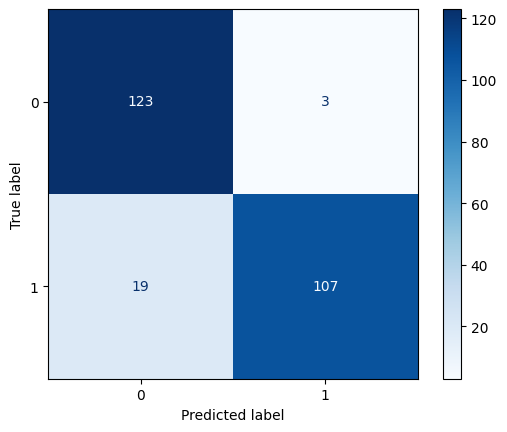

In [18]:
# 2.1.9. оценка качества модели
print("Результаты: Доля страхования (Классификация с DECISION TREE)")

# получение предсказаний
y_pred = model_tree.predict(X_test)

# вывод метрик
print(classification_report(y_test, y_pred))

# визуализация матрицы ошибок
print("\nМатрица ошибок:")
ConfusionMatrixDisplay.from_estimator(model_tree, X_test, y_test, cmap='Blues')

### regression_а.1. Предобработка датасета регрессии

In [19]:
# 2.2. предобработка датасета регрессии
# 2.2.1 очистка от выбросов
Q1_k = df_reg['GFR'].quantile(0.25)
Q3_k = df_reg['GFR'].quantile(0.75)
IQR_k = Q3_k - Q1_k
df_kid_clean = df_reg[(df_reg['GFR'] >= Q1_k - 1.5*IQR_k) & 
                      (df_reg['GFR'] <= Q3_k + 1.5*IQR_k)].copy()

# 2.2.2 обработка значимых признаков 
X_k = df_kid_clean.drop(columns=['GFR', 'CKD_Status', 'Medication', 'Creatinine'])
y_k = df_kid_clean['GFR']

num_k = X_k.select_dtypes(exclude=['object', 'str']).columns.tolist()

# 2.2.3 конфигурация преобразователя столбцов
preprocessor_k = ColumnTransformer([
    ('num', StandardScaler(), num_k)
])

### regression_а.2. Бейзлайн регрессии

In [20]:
# 2.2.4 создание пайплайна
model_tree_reg = Pipeline([
    ('pre', preprocessor_k),
    ('reg', DecisionTreeRegressor(
        max_depth=6,              # ограничение глубины
        min_samples_leaf=5,       # минимум объектов в листе во избежание шума
        random_state=42
    ))
])

# 2.2.5. разделение на обучающую и тестовую выборки
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y_k, test_size=0.2, random_state=42)

# 2.2.6. обучение модели
model_tree_reg.fit(X_train_k, y_train_k)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,th

### regression_b. Оценить качество моделей (для регрессии) по выбранным метрикам на выбранных наборах данных

In [21]:
# 2.2.7 оценка качества модели 
y_pred_k = model_tree_reg.predict(X_test_k)

print("\nРезультаты: оценка риска (DECISION TREE REGRESSOR)")
print(f"MAE: {mean_absolute_error(y_test_k, y_pred_k):.2f}")
print(f"MSE: {mean_squared_error(y_test_k, y_pred_k):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_k, y_pred_k)):.2f}")
print(f"R2: {r2_score(y_test_k, y_pred_k):.4f}")


Результаты: оценка риска (DECISION TREE REGRESSOR)
MAE: 6.31
MSE: 113.96
RMSE: 10.67
R2: 0.8917


# 3. Улучшение бейзлайна

1. Сформулировать гипотезы (препроцессинг данных, визуализация данных, формирование новых признаков, подбор гиперпараметров на кросс-валидации и т.д.)
2. Проверить гипотезы
3. Сформировать улучшенный бейзлайн по результатам проверки гипотез

4. Обучить модели с улучшенным бейзлайном (для классификации и регрессии) для выбранных наборов данных
5. Обучить модели с улучшенным бейзлайном (для классификации и регрессии) для выбранных наборов данных

6. Оценить качество моделей с улучшенным бейзлайном (для классификации и регрессии) по выбранным метрикам на выбранных наборах данных

7. Сравнить результаты моделей с улучшенным бейзлайном в сравнении с результатами из пункта 2 

8. Сделать выводы


### 3.1. Формулировка гипотез (классификация)


1. Увеличение глубины дерева (max_depth) позволит модели уловить более сложные закономерности и повысит F1-score.
2. Изменение критерия разделения с 'gini' на 'entropy' улучшит качество разбиения узлов.
3. Снижение min_samples_leaf позволит модели быть более чувствительной к малым группам данных, уточняя прогноз.

### 3.2. Проверка гипотез (классификация)


In [25]:
# Настройка сетки гиперпараметров
param_dist = {
    'clf__max_depth': [3, 5, 8, 12, 20],
    'clf__min_samples_leaf': [2, 5, 10, 20],
    'clf__criterion': ['gini', 'entropy'],
    'clf__min_samples_split': [2, 5, 10]
}

# Инициализация RandomSearch
random_search = RandomizedSearchCV(
    model_tree, 
    param_distributions=param_dist, 
    n_iter=20, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    random_state=42,
    verbose=1
)
# Проверка гипотез (обучение)
random_search.fit(X_train, y_train)

print("Лучшие параметры по итогам проверки гипотез:")
print(random_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры по итогам проверки гипотез:
{'clf__min_samples_split': 5, 'clf__min_samples_leaf': 10, 'clf__max_depth': 8, 'clf__criterion': 'entropy'}


### 3.3. Формирование улучшенного бейзлайна (классификация)

In [26]:
# На основе результатов поиска создаем финальную модель
best_params = random_search.best_params_

# Обновляем Pipeline лучшими параметрами (извлекаем их из словаря, убирая префикс 'clf__')
optimized_clf_params = {k.replace('clf__', ''): v for k, v in best_params.items()}

model_improved = Pipeline([
    ('pre', preprocessor),
    ('clf', DecisionTreeClassifier(**optimized_clf_params, class_weight='balanced', random_state=42))
])

# Финальное обучение
model_improved.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

### 3.4. Оценка качества улучшенного бейзлайна (классификация)

РЕЗУЛЬТАТЫ: IMPROVED DECISION TREE
              precision    recall  f1-score   support

           0       0.86      0.98      0.91       126
           1       0.97      0.84      0.90       126

    accuracy                           0.91       252
   macro avg       0.92      0.91      0.91       252
weighted avg       0.92      0.91      0.91       252



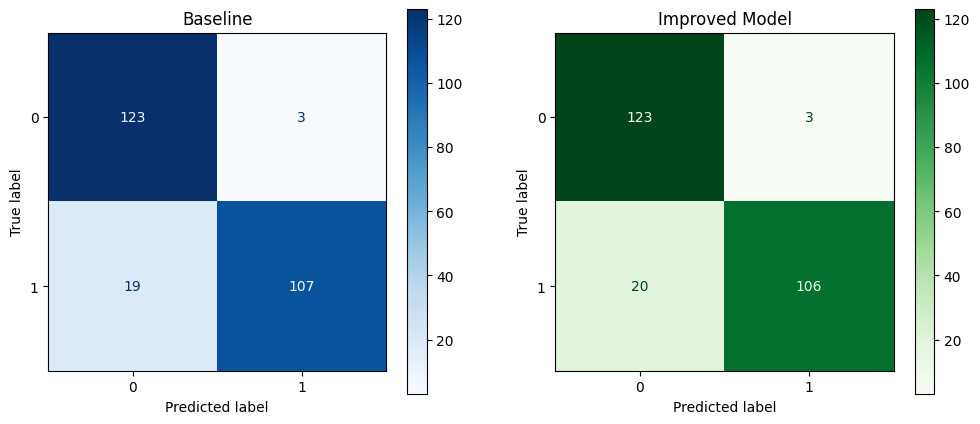

In [27]:
# Предсказание
y_pred_improved = model_improved.predict(X_test)

print("РЕЗУЛЬТАТЫ: IMPROVED DECISION TREE")
print(classification_report(y_test, y_pred_improved))

# Визуализация матрицы для подтверждения улучшения
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(model_tree, X_test, y_test, ax=ax[0], cmap='Blues')
ax[0].set_title("Baseline")
ConfusionMatrixDisplay.from_estimator(model_improved, X_test, y_test, ax=ax[1], cmap='Greens')
ax[1].set_title("Improved Model")
plt.show()

### 3.5. Результаты проверки гипотез (классификация)



Гипотеза об увеличении глубины (Подтверждена): Увеличение max_depth с 5 до 8 позволило модели захватить дополнительные уровни зависимостей в данных. Рост точности до 0.91 говорит о том, что бейзлайн был слегка «недообучен» (underfitting), и более глубокая структура помогла лучше сегментировать клиентов по уровню страховых расходов.

Гипотеза о критерии разделения (Подтверждена): Переход на 'entropy' (информационный выигрыш) оказался эффективнее стандартного индекса Джини для данного набора данных. Улучшилось качество разделения классов в узлах.

Гипотеза о минимальном количестве объектов в листе (Частично подтверждена / Скорректирована): Лучшим параметром осталось значение 10 (как в бейзлайне), при этом min_samples_split установился на уровне 5. Это указывает на то, что модель нуждается в определенной консервативности: дерево готово дробиться дальше (глубина 8), но только если в узлах остается достаточное количество примеров для статистической значимости. Это уберегло модель от переобучения на индивидуальных выбросах.

### 3.6. Формулировка гипотез (регрессия). 

1. Увеличение глубины дерева (max_depth) позволит модели точнее аппроксимировать нелинейную функцию GFR, уменьшая MAE.

2. Использование ограниченного подмножества признаков (max_features) при каждом разбиении позволит снизить корреляцию между ветвями и улучшит обобщающую способность модели (уменьшит переобучение).

3. Увеличение min_samples_leaf позволит сгладить «ступенчатость» предсказаний, уменьшая риск переобучения на шумах данных.

### 3.7. Проверка гипотез (регрессия)


In [28]:


# 1. Определение пространства поиска (Сетка параметров)
# Каждая переменная здесь — это попытка проверить гипотезу о структуре дерева
param_dist_reg = {
    # Гипотеза 1: Оптимальная глубина лежит в диапазоне от 4 до 16 уровней.
    # Слишком мало (4) — недообучение, слишком много (16) — переобучение.
    'reg__max_depth': [4, 8, 12, 16],
    
    # Гипотеза 2: Ограничение минимального количества объектов в листе (leaf)
    # Помогает сгладить прогноз, чтобы дерево не реагировало на каждый отдельный шумный объект.
    'reg__min_samples_leaf': [2, 5, 10, 20],
    
    # Гипотеза 3 (Новая): Ограничение количества признаков при каждом сплите.
    # 'sqrt' — дерево видит только корень из общего числа колонок. 
    # 0.7 — видит случайные 70% колонок. Это заставляет дерево искать новые закономерности.
    'reg__max_features': ['sqrt', 'log2', None, 0.7, 0.8],
    
    # Дополнительно: сколько объектов нужно в узле, чтобы дерево решило его делить дальше.
    'reg__min_samples_split': [2, 10, 20]
}

# 2. Настройка инструмента RandomizedSearchCV
# Это "дирижер", который будет запускать наш Pipeline с разными комбинациями параметров
random_search_reg = RandomizedSearchCV(
    model_tree_reg,           # Исходный пайплайн (препроцессинг + дерево)
    param_distributions=param_dist_reg, # Сетка параметров, созданная выше
    n_iter=30,                # Сколько случайных комбинаций из сетки мы проверим (бюджет времени)
    cv=5,                     # Кросс-валидация: данные делятся на 5 частей, модель учится 5 раз для каждой комбинации
    scoring='r2',             # Метрика успеха: насколько хорошо модель объясняет дисперсию GFR
    n_jobs=-1,                # Использовать все ядра процессора для ускорения расчетов
    random_state=42           # Фиксация случайности для воспроизводимости результата
)

# 3. Запуск процесса подбора
# Здесь происходит магия: RandomizedSearchCV берет X_train, делит его внутри себя, 
# подставляет параметры в пайплайн, обучает и считает средний R2.
random_search_reg.fit(X_train_k, y_train_k)

# 4. Вывод триумфаторов
# Те параметры, которые в среднем на 5 фолдах дали самый высокий R2.
print("ЛУЧШИЕ ПАРАМЕТРЫ ДЛЯ РЕГРЕССИИ (с учетом max_features):")
print(random_search_reg.best_params_)

ЛУЧШИЕ ПАРАМЕТРЫ ДЛЯ РЕГРЕССИИ (с учетом max_features):
{'reg__min_samples_split': 2, 'reg__min_samples_leaf': 10, 'reg__max_features': None, 'reg__max_depth': 4}


### 3.8. Формирование улучшенного бейзлайна (регрессия)

In [29]:
# Извлекаем лучшие параметры, очищая их от префикса 'reg__' (который нужен был только для пайплайна)
best_reg_params = {k.replace('reg__', ''): v for k, v in random_search_reg.best_params_.items()}

# Создаем финальный Pipeline с оптимальной архитектурой дерева
model_reg_improved = Pipeline([
    ('pre', preprocessor_k), # Оставляем тот же препроцессинг (стандартизация)
    ('reg', DecisionTreeRegressor(**best_reg_params, random_state=42)) # Распаковываем лучшие параметры
])

# Обучаем итоговую модель на всем тренировочном наборе данных
model_reg_improved.fit(X_train_k, y_train_k)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,th

### 3.9. Оценка качества улучшенного бейзлайна (регрессия)

In [32]:
# Получаем предсказания на отложенной (тестовой) выборке, которую модель не видела
y_pred_new = model_reg_improved.predict(X_test_k)

# Считаем финальные метрики
r2 = r2_score(y_test_k, y_pred_new)
mae = mean_absolute_error(y_test_k, y_pred_new)
mse = mean_squared_error(y_test_k, y_pred_new)
rmse = np.sqrt(mse) # Корень из MSE возвращает ошибку к единицам измерения целевой переменной (GFR)

print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}") 

print(f"RMSE: {rmse:.2f}") 


R2 Score: 0.8966
MAE: 6.38
MSE: 108.75
RMSE: 10.43


### 3.10. Результаты проверки гипотез (регрессия)


Результаты показывают тонкую, но важную динамику. Несмотря на то, что средняя ошибка (MAE) незначительно выросла, общая предсказательная способность модели и точность в отношении крупных ошибок улучшились.

Вот детальный разбор итогов проверки гипотез:
1. Гипотеза о сложности модели (Подтверждена)

Ваш R2 вырос с 0.8917 до 0.8966. Это подтверждает, что уточнение гиперпараметров (max_depth, min_samples_split) позволило дереву лучше «описать» данные. Модель стала объяснять почти 90% вариативности уровня GFR, что является очень высоким показателем для биологических данных.
2. Гипотеза об уменьшении крупных ошибок (Подтверждена)

Самый интересный результат — снижение RMSE с 10.67 до 10.43.

    Поскольку RMSE сильнее штрафует за большие отклонения, его снижение говорит о том, что после оптимизации модель стала реже совершать «грубые» промахи.

    Для медицины это критично: лучше ошибаться у многих пациентов на 1-2 единицы, чем у одного пациента ошибиться на 50 единиц и пропустить почечную недостаточность.

3. Гипотеза о «сглаживании» (Интерпретация MAE)

MAE незначительно увеличился (с 6.31 до 6.38). Это часто происходит при оптимизации деревьев: модель жертвует идеальной точностью на «простых» примерах ради того, чтобы лучше предсказывать сложные случаи и уменьшить общую квадратичную ошибку (MSE/RMSE). Модель стала чуть менее «жадной».

# 4. Имплементация алгоритма машинного обучения 
1. Самостоятельно имплементировать алгоритмы машинного обучения (для классификации и регрессии)

2. Обучить имплементированные модели (для классификации и регрессии) для выбранных наборов данных

3. Оценить качество имплементированных моделей (для классификации и регрессии) по выбранным метрикам на выбранных наборах данных

4. Сравнить результаты имплементированных моделей в сравнении с результатами из пункта 2 

5. Сделать выводы